In [3]:
!pip install pandarallel

  Preparing metadata (setup.py) ... done
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16672 sha256=9c699f8e294f96d8eeec54e52ae98d2fbb20f57abe59c0f846700abc506db042
  Stored in directory: /root/.cache/pip/wheels/50/4f/1e/34e057bb868842209f1623f195b74fd7eda229308a7352d47f
Successfully built pandarallel


In [4]:
import warnings

warnings.filterwarnings("ignore")

import os
import re
import nltk

nltk.download("wordnet")
nltk.download("stopwords")
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchtext
from nltk.corpus import stopwords
from pandarallel import pandarallel
from torch.utils.data import DataLoader, TensorDataset
from torchtext import vocab
from tqdm import tqdm

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
pandarallel.initialize(progress_bar=True)

INFO: Pandarallel will run on 2 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [6]:
train_data = pd.read_csv(r"/kaggle/input/emotion-dataset/training.csv")
val_data = pd.read_csv(r"/kaggle/input/emotion-dataset/validation.csv")
test_data = pd.read_csv(r"/kaggle/input/emotion-dataset/test.csv")

In [7]:
class Preprocessor:
    def __init__(
        self,
        max_length,
        min_freq,
        sos_token,
        eos_token,
        unk_token,
        pad_token,
        shuffle=False,
        batch_size=16,
        stopwords=[]
    ):
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.max_length = max_length
        self.min_freq = min_freq
        self.sos_token = sos_token
        self.eos_token = eos_token
        self.unk_token = unk_token
        self.pad_token = pad_token
        self.stopwords = stopwords

        self.special_tokens = [unk_token, pad_token, sos_token, eos_token]


    def clean(self, data):
        self.nlp = spacy.load("en_core_web_sm")

        lemmatize = lambda text: " ".join(
            x
            for x in map(lambda token: token.lemma_, self.nlp(text))
            if x not in self.stopwords
        )

        print("Lemmatizing...")
        data["clean_text"] = data["text"].parallel_apply(lemmatize).str.lower()
        print("Lemmatizing Done!")

        return data

    def tokenize(self, text, max_length, sos_token, eos_token):
        tokens = [token.text for token in self.nlp.tokenizer(text)][:max_length]
        en_tokens = [sos_token] + tokens + [eos_token]
        return en_tokens

    def convert_numerical(self, tokens):
        en_ids = self.vocab.lookup_indices(tokens)
        return en_ids

    def fit(self, data):

        data = self.clean(data)
        print("Tokenizing Started...")
        data["tokens"] = data["clean_text"].map(
            lambda x: self.tokenize(
                str(x), self.max_length, self.sos_token, self.eos_token
            )
        )
        print("Tokenizing Done!")
        self.vocab = vocab.build_vocab_from_iterator(
            data["tokens"], min_freq=self.min_freq, specials=self.special_tokens
        )
        unk_index = self.vocab[self.unk_token]
        self.vocab.set_default_index(unk_index)

    def pad_sequences(self, sequences, pad_token):
        max_seq_len = self.max_length + 2
        
        padded_sequences = [
            seq + [pad_token] * (max_seq_len - len(seq)) for seq in sequences
        ]
        return padded_sequences

    def transform(self, data, return_float=True):
        if "clean_text" not in data.columns:
            data = self.clean(data)
        if "tokens" not in data.columns:
            data["tokens"] = data["clean_text"].map(
                lambda x: self.tokenize(
                    str(x), self.max_length, self.sos_token, self.eos_token
                )
            )

        # Convert tokens to numerical indices
        data["numerical_tokens"] = data.tokens.map(self.convert_numerical)

        # Pad sequences
        padded_sequences = self.pad_sequences(
            data["numerical_tokens"].to_list(), self.vocab[self.pad_token]
        )

        X = np.array(padded_sequences)
        y = data.label.to_numpy()

        if return_float:
            X_tensor = torch.tensor(X, dtype=torch.float32)
            y_tensor = torch.tensor(y, dtype=torch.float32)
        else:
            X_tensor = torch.tensor(X, dtype=torch.long)
            y_tensor = torch.tensor(y, dtype=torch.long)

        iterable_data = DataLoader(
            dataset=TensorDataset(X_tensor, y_tensor),
            batch_size=self.batch_size,
            shuffle=self.shuffle,
        )

        return iterable_data

In [8]:
%%time

processor = Preprocessor(
    shuffle=True,
    batch_size=32,
    max_length=40,
    min_freq=2,
    sos_token="<sos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>",
    # stopwords=stopwords.words('english') 
)

processor.fit(train_data)


train_dataset = processor.transform(train_data)
val_dataset = processor.transform(val_data)
test_dataset = processor.transform(test_data)

Lemmatizing...


Lemmatizing Done!
Tokenizing Started...
Tokenizing Done!
Lemmatizing...


Lemmatizing Done!
Lemmatizing...


Lemmatizing Done!
CPU times: user 11.7 s, sys: 805 ms, total: 12.5 s
Wall time: 1min 34s


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
def accuracy_fn(y_true, y_pred):
    correct = (
        torch.eq(y_true, y_pred).sum().item()
    )  
    acc = (correct / len(y_pred)) * 100
    return acc


def evaluate(model, data_loader, device):

    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:

            X = X.to(device)
            y = y.type(torch.LongTensor)
            y = y.to(device)
            y_pred = model(X)
            
            y_pred_class = nn.functional.softmax(y_pred, dim=1).argmax(dim=1)

            loss += criterion(y_pred, y).item()
            acc += accuracy_fn(y, y_pred_class)

    acc /= len(data_loader)
    loss /= len(data_loader)

    return acc, loss


def trainer(model, device, train_data, epochs, criterion, optimizer, val_data=None):

    history = {
        "train_loss": [],
        "train_acc": [],
        "epoch": [],
    }

    if val_data:
        history["val_loss"] = []
        history["val_acc"] = []

    model = model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()

        for batch, (X, y) in tqdm(enumerate(train_data), total=len(train_data)):

            X = X.to(device)
            y = y.type(torch.LongTensor)
            y = y.to(device)
            y_pred = model(X)
            y_pred_class = nn.functional.softmax(y_pred, dim=1).argmax(dim=1)

            loss = criterion(y_pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_acc, train_loss = evaluate(model, train_data, device)
        if val_data:
            val_acc, val_loss = evaluate(model, val_data, device)

        for key in history.keys():
            history[key].append(locals()[key])

        print(f"Epoch: {epoch}/{epochs}")
        print(f"Training ---|  Accuracy: {train_acc:.2f} Loss: {train_loss:.5f}")
        if val_data:
            print(f"Validation ---|  Accuracy: {val_acc:.2f} Loss: {val_loss:.5f}")

    return history


def plot(df):
    plt.figure(figsize=(12, 6))

    # Plotting train_loss and val_loss
    plt.subplot(1, 2, 1)
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train and Validation Loss")
    plt.legend()

    # Plotting train_acc and val_acc
    plt.subplot(1, 2, 2)
    plt.plot(df["epoch"], df["train_acc"], label="Train Accuracy")
    plt.plot(df["epoch"], df["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Train and Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

## Fully Connected Network

In [14]:
len(processor.vocab)

5890

In [15]:
%%time


class ANN(nn.Module):
    def __init__(self, input_size, n_class):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, n_class)

    def forward(self, features):

        out = self.fc2(F.relu(self.fc1(features)))

        return out


model = ANN(input_size=42, n_class=6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)


history = trainer(
    model,
    epochs=40,
    device=device,
    train_data=train_dataset,
    val_data=val_dataset,
    criterion=criterion,
    optimizer=optimizer,
)

100%|██████████| 500/500 [00:01<00:00, 405.44it/s]


Epoch: 1/40
Training ---|  Accuracy: 25.57 Loss: 12.97559
Validation ---|  Accuracy: 22.32 Loss: 12.98471


100%|██████████| 500/500 [00:00<00:00, 651.03it/s]


Epoch: 2/40
Training ---|  Accuracy: 25.60 Loss: 5.53998
Validation ---|  Accuracy: 22.67 Loss: 5.91065


100%|██████████| 500/500 [00:00<00:00, 619.79it/s]


...

Epoch: 38/40
Training ---|  Accuracy: 34.89 Loss: 1.54606
Validation ---|  Accuracy: 34.52 Loss: 1.66151


100%|██████████| 500/500 [00:00<00:00, 656.70it/s]


Epoch: 39/40
Training ---|  Accuracy: 34.93 Loss: 1.54625
Validation ---|  Accuracy: 35.07 Loss: 1.68494


100%|██████████| 500/500 [00:00<00:00, 656.92it/s]


Epoch: 40/40
Training ---|  Accuracy: 34.90 Loss: 1.54280
Validation ---|  Accuracy: 34.72 Loss: 1.70516
CPU times: user 45.4 s, sys: 1.21 s, total: 46.6 s
Wall time: 48.8 s


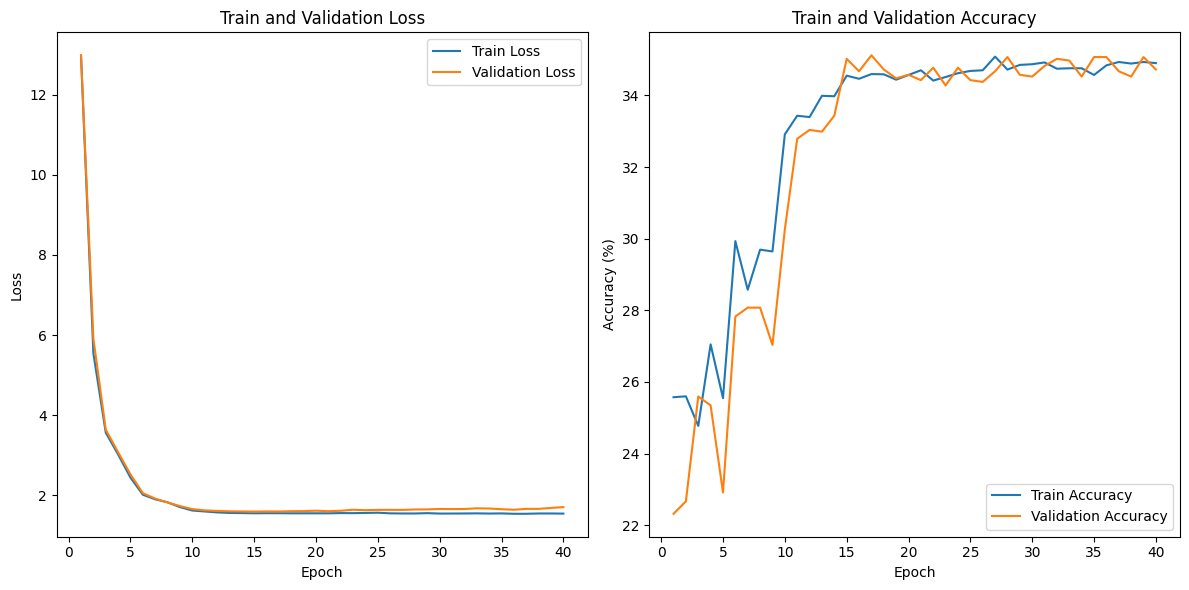

In [16]:
res = pd.DataFrame(history)
plot(res)

In [17]:
evaluate(model, test_dataset, device)

(34.47420634920635, 1.6700121448153542)

### Train LSTM using embedding

In [18]:
%%time


class LSTMNetwork(nn.Module):
    def __init__(self, n_class):
        super().__init__()
        self.embeddings = nn.Embedding(len(processor.vocab), 32)
        self.lstm = nn.LSTM(32, 64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, n_class)

    def forward(self, features):
        features = features.type(torch.long)
        emb = self.embeddings(features)
        # print(emb.shape)
        out, _ = self.lstm(emb)
        out = self.fc(out[:, -1, :])  # Use the output from the last time step
        return out


model_lstm = LSTMNetwork(n_class=6).to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_lstm.parameters(), lr=0.01)

# Assuming trainer is a function that handles the training loop
history = trainer(
    model_lstm,
    epochs=40,
    device=device,
    train_data=train_dataset,
    val_data=val_dataset,
    criterion=criterion,
    optimizer=optimizer,
)

100%|██████████| 500/500 [00:01<00:00, 260.80it/s]


Epoch: 1/40
Training ---|  Accuracy: 33.51 Loss: 1.57696
Validation ---|  Accuracy: 35.32 Loss: 1.57852


100%|██████████| 500/500 [00:01<00:00, 384.27it/s]


Epoch: 2/40
Training ---|  Accuracy: 33.54 Loss: 1.57385
Validation ---|  Accuracy: 35.37 Loss: 1.58176


100%|██████████| 500/500 [00:01<00:00, 379.50it/s]


...

Epoch: 38/40
Training ---|  Accuracy: 97.48 Loss: 0.07169
Validation ---|  Accuracy: 89.48 Loss: 0.36986


100%|██████████| 500/500 [00:01<00:00, 380.62it/s]


Epoch: 39/40
Training ---|  Accuracy: 97.24 Loss: 0.08110
Validation ---|  Accuracy: 89.24 Loss: 0.37110


100%|██████████| 500/500 [00:01<00:00, 377.84it/s]


Epoch: 40/40
Training ---|  Accuracy: 98.16 Loss: 0.05385
Validation ---|  Accuracy: 89.53 Loss: 0.36002
CPU times: user 1min 15s, sys: 1.15 s, total: 1min 16s
Wall time: 1min 17s


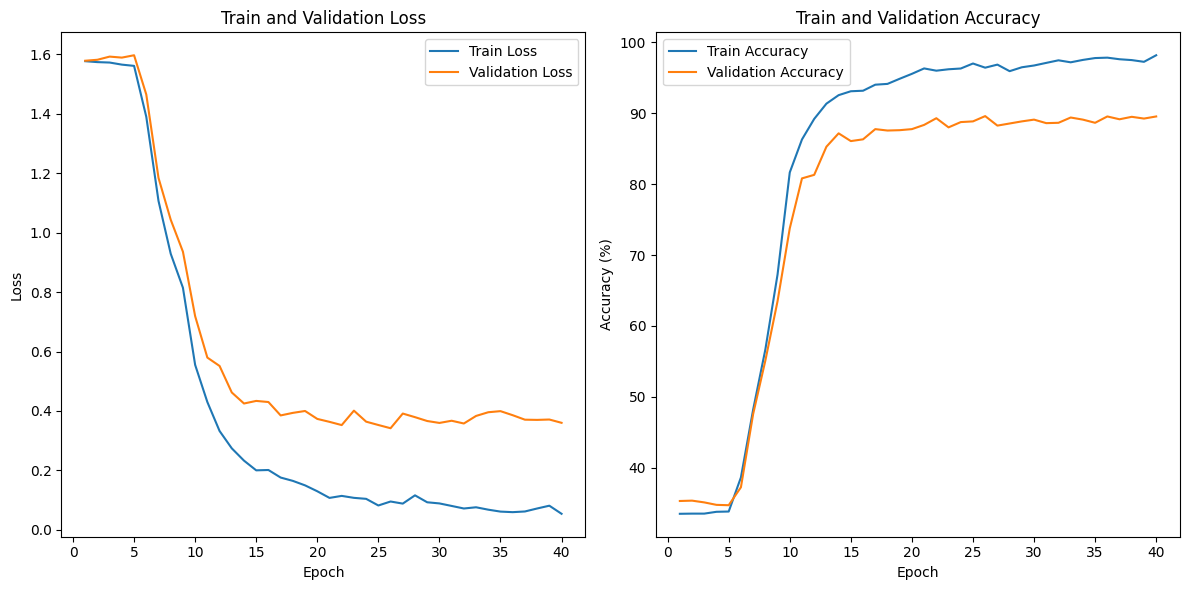

In [19]:
res = pd.DataFrame(history)
plot(res)

In [20]:
evaluate(model_lstm, test_dataset, device="cuda")

(88.88888888888889, 0.4206605160697585)